In [148]:
# Importing Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [149]:
# Loading Dataset

df = pd.read_csv('ford.csv')
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2


# EDA

In [150]:
df.shape

(17966, 9)

In [151]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [152]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [153]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  str    
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  str    
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  str    
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 1.6 MB


In [154]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [155]:
df.duplicated().sum()

np.int64(154)

In [156]:
df.drop_duplicates(inplace=True)

In [157]:
df.duplicated().sum()

np.int64(0)

In [158]:
df.shape

(17812, 9)

In [159]:
numeric_col = df.select_dtypes(include=[int,float])
numeric_col

,year,price,mileage,tax,mpg,engineSize
0,2017,12000,15944,150,57.7,1.0
1,2018,14000,9083,150,57.7,1.0
2,2017,13000,12456,150,57.7,1.0
3,2019,17500,10460,145,40.3,1.5
4,2019,16500,1482,145,48.7,1.0
...,...,...,...,...,...,...
17961,2017,8999,16700,150,47.1,1.4
17962,2014,7499,40700,30,57.7,1.0
17963,2015,9999,7010,20,67.3,1.6
17964,2018,8299,5007,145,57.7,1.2


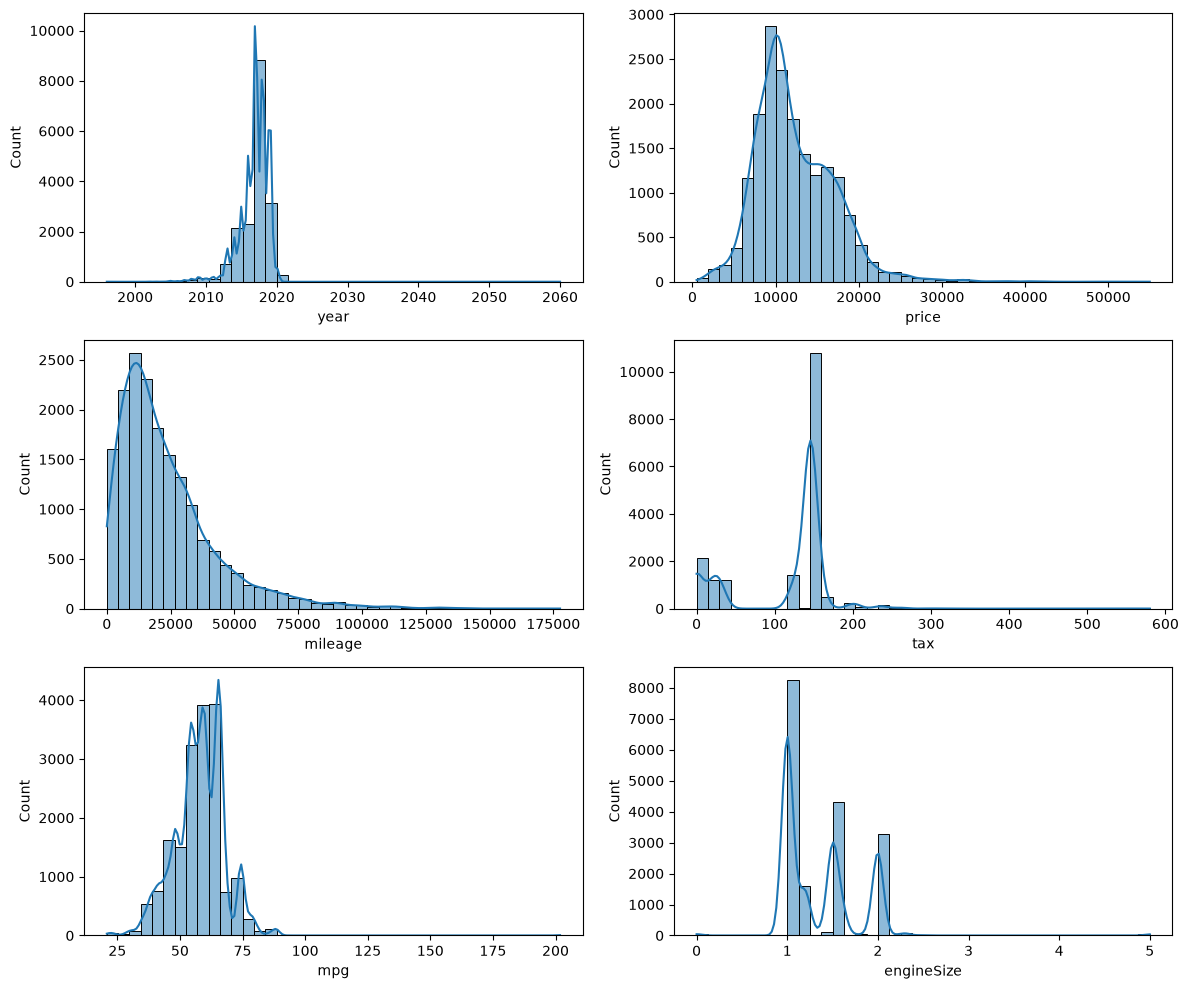

In [160]:
# Plotting Histogram to check distribution of data

plt.figure(figsize=(12,10))
for num, col in enumerate(numeric_col):
    plt.subplot(3,2,num+1)
    sns.histplot(data=df[col], kde=True, bins=40)

plt.tight_layout()
plt.show()

In [161]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='str')

In [162]:
categorical_col = df.select_dtypes(include=str)
categorical_col

,model,transmission,fuelType
0,Fiesta,Automatic,Petrol
1,Focus,Manual,Petrol
2,Focus,Manual,Petrol
3,Fiesta,Manual,Petrol
4,Fiesta,Automatic,Petrol
...,...,...,...
17961,B-MAX,Manual,Petrol
17962,B-MAX,Manual,Petrol
17963,Focus,Manual,Diesel
17964,KA,Manual,Petrol


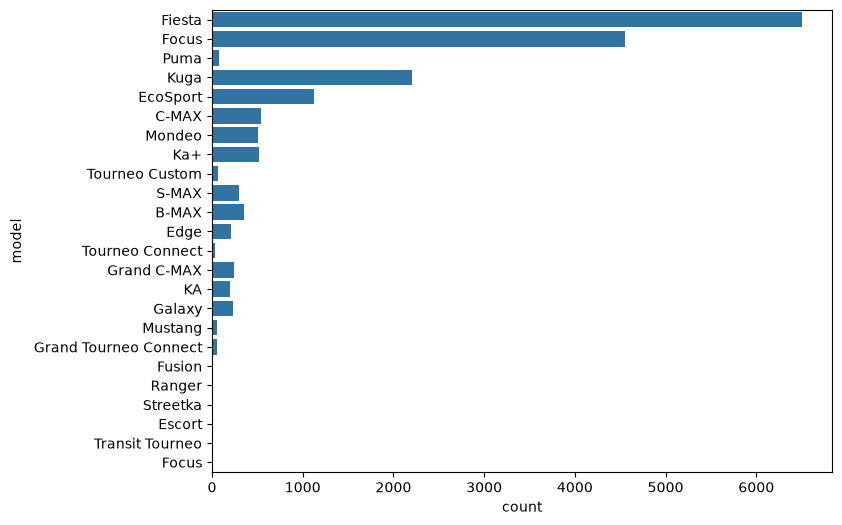

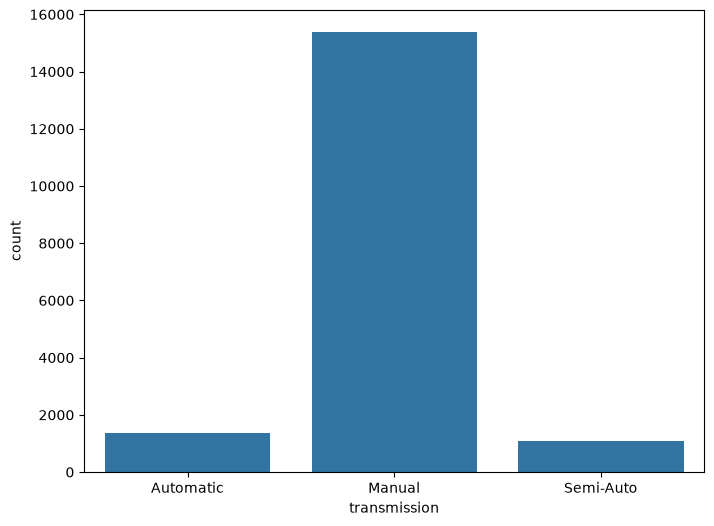

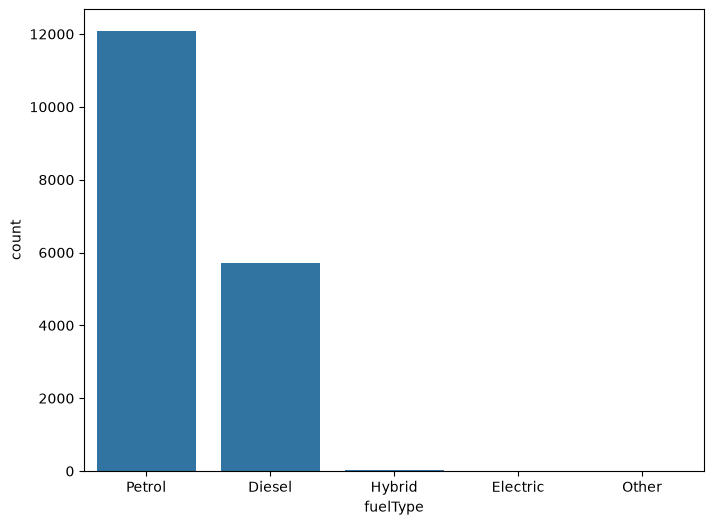

In [163]:
# Plotting Countplot

for col in categorical_col:
    plt.figure(figsize=(8,6))
    if col == 'model':
        sns.countplot(y= df[col])
    else:
        sns.countplot(x= df[col])

In [164]:
df['fuelType'].value_counts()

fuelType
Petrol      12081
Diesel       5706
Hybrid         22
Electric        2
Other           1
Name: count, dtype: int64

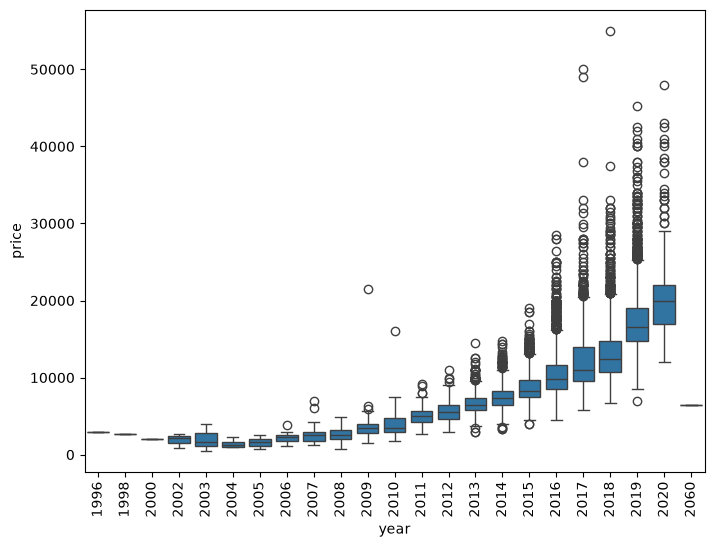

In [165]:
# Plotting Boxplot to check relationship between target (price)

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='year', y='price')
plt.xticks(rotation=90)
plt.show()

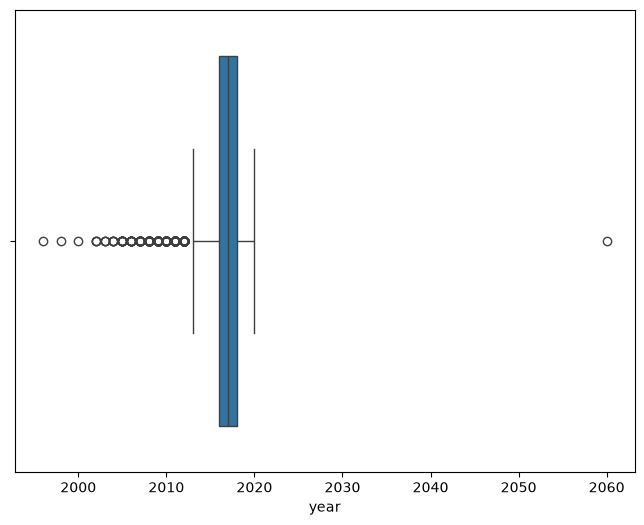

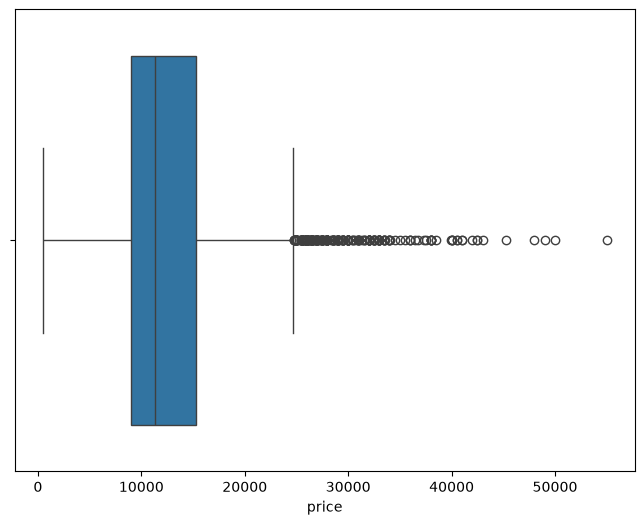

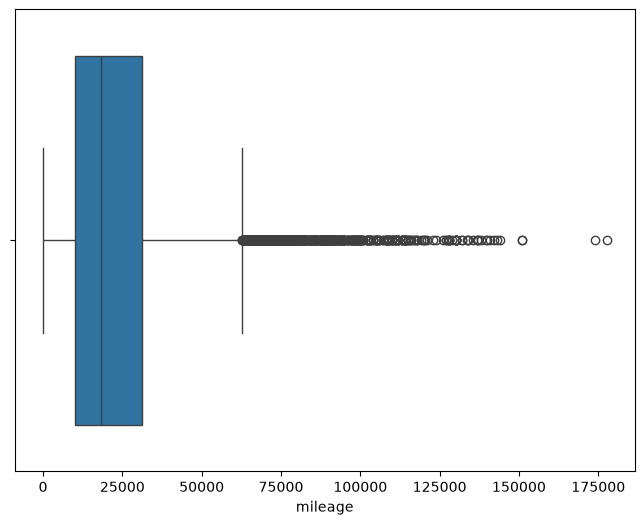

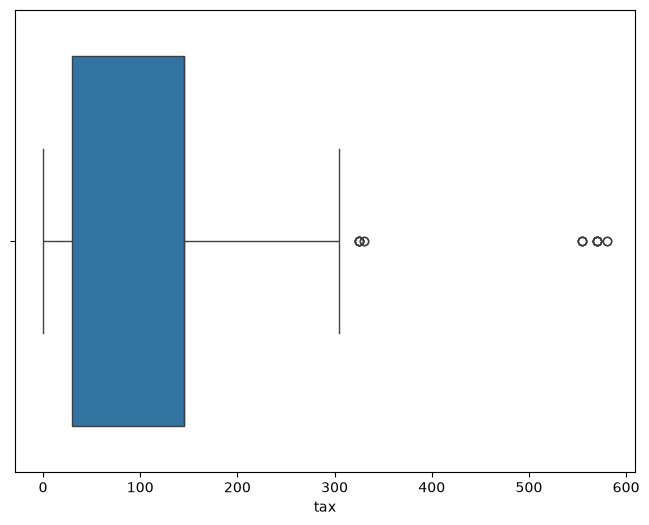

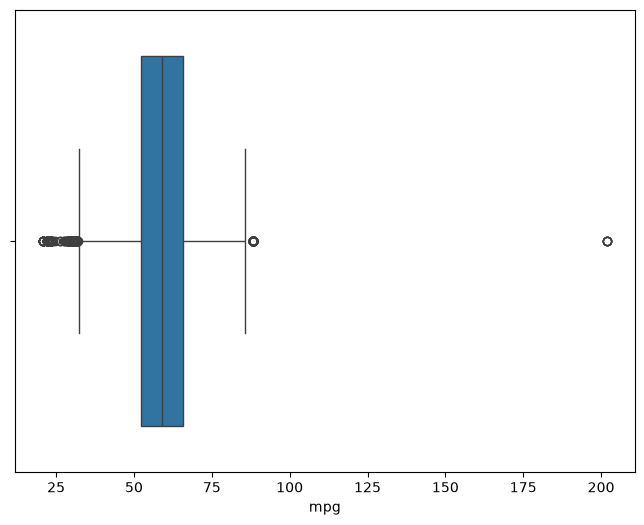

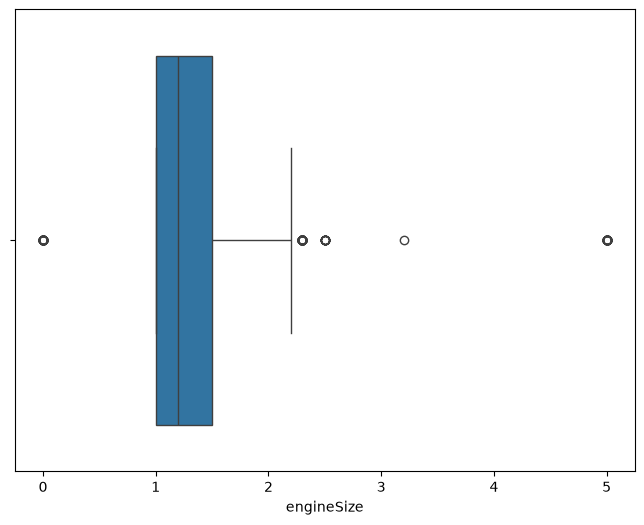

In [166]:
# Plotting Boxplot for each numeric column to spot outliers

for col in numeric_col:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df[col])
    

<Axes: >

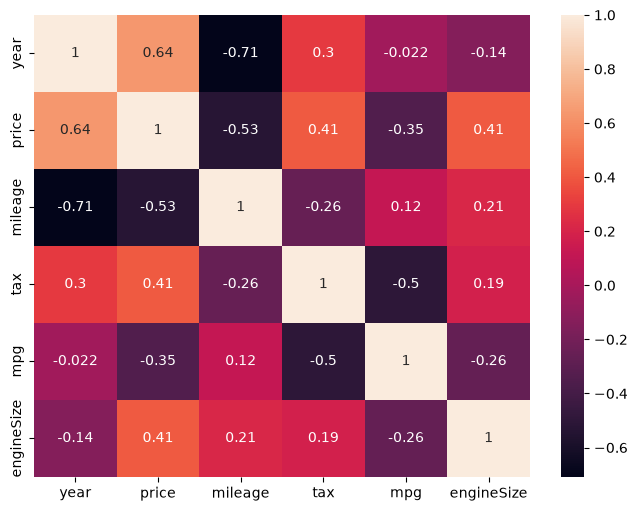

In [167]:
# Checking Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [168]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='str')

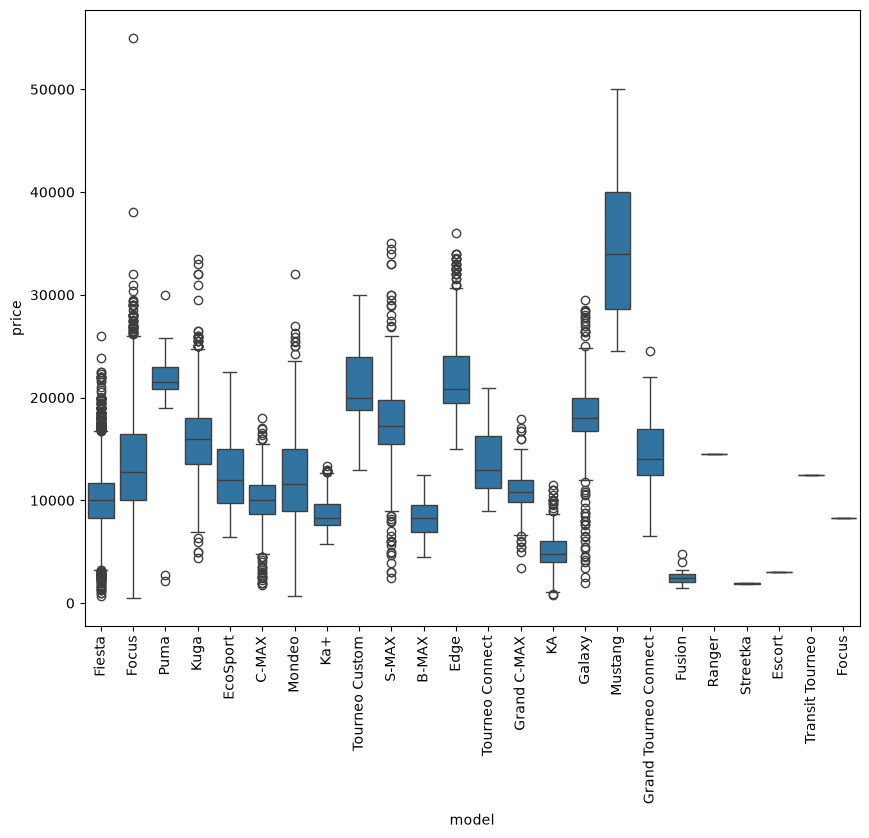

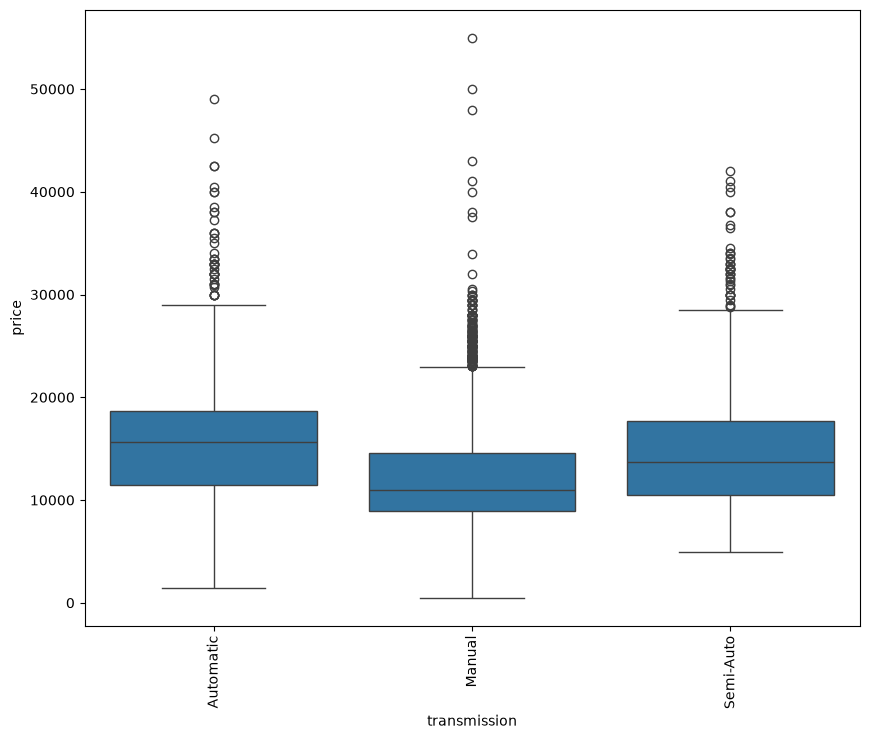

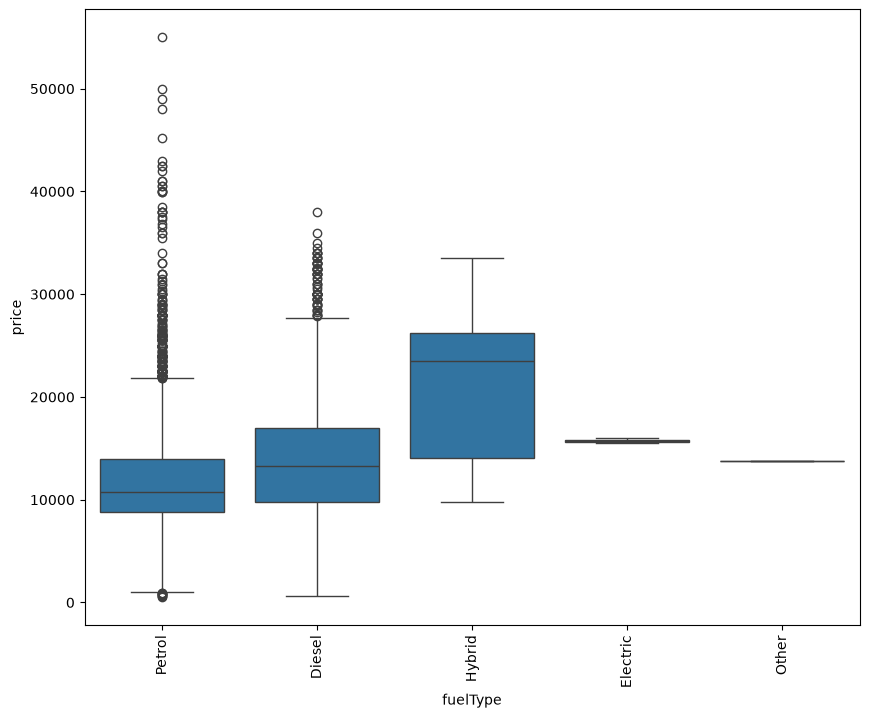

In [169]:
# Plotting Boxplot to check categorical columns relationship with target (price)

for col in categorical_col:
    plt.figure(figsize=(10,8))
    sns.boxplot(data=df, x=col, y='price')
    plt.xticks(rotation=90)
    plt.show()

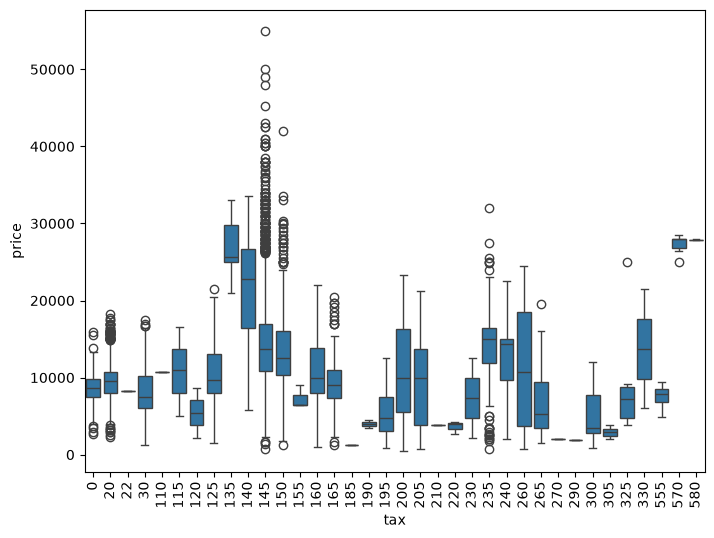

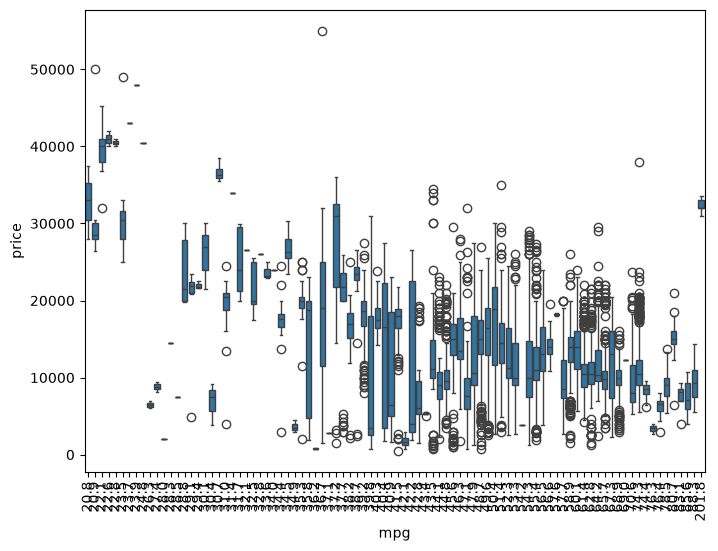

In [170]:
# Boxplot for tax and mpg column

plt.figure(figsize=(8,6))
sns.boxplot(data = df, x = 'tax', y = 'price')
plt.xticks(rotation=90)
plt.figure(figsize=(8,6))
sns.boxplot(data = df, x = 'mpg', y = 'price')
plt.xticks(rotation=90)
plt.show()

In [171]:
# Converting Feature (x) and Target (y)

X = df.drop(columns='price')
y = df['price']

In [172]:
# Importing Encoder from Scikit-Learn

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [173]:
# Setting all transformers to output pandas DataFrames globally

from sklearn import set_config

set_config(transform_output="pandas")

In [174]:
# Changing Categorical Columns to Numeric

categorial_columns_to_transform = ['model', 'transmission', 'fuelType']

one_hot_transformer = ColumnTransformer(transformers=[('cat', OneHotEncoder(sparse_output=False), categorial_columns_to_transform)], remainder='passthrough')

X_encoded = one_hot_transformer.fit_transform(X)
X_encoded

,cat__model_ B-MAX,cat__model_ C-MAX,cat__model_ EcoSport,cat__model_ Edge,cat__model_ Escort,cat__model_ Fiesta,cat__model_ Focus,cat__model_ Fusion,cat__model_ Galaxy,cat__model_ Grand C-MAX,...,cat__fuelType_Diesel,cat__fuelType_Electric,cat__fuelType_Hybrid,cat__fuelType_Other,cat__fuelType_Petrol,remainder__year,remainder__mileage,remainder__tax,remainder__mpg,remainder__engineSize
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2017,15944,150,57.7,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2018,9083,150,57.7,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2017,12456,150,57.7,1.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2019,10460,145,40.3,1.5
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2019,1482,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2017,16700,150,47.1,1.4
17962,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2014,40700,30,57.7,1.0
17963,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,2015,7010,20,67.3,1.6
17964,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2018,5007,145,57.7,1.2


In [175]:
# Standardization implementing Standard Scalar

from sklearn.preprocessing import StandardScaler

In [176]:
scalar = StandardScaler()

numeric_columns_to_transform = ['remainder__year','remainder__mileage', 'remainder__tax','remainder__mpg','remainder__engineSize']

scalar_transformer = ColumnTransformer(transformers=[('num', StandardScaler(), numeric_columns_to_transform)], remainder='passthrough')

X_scaled = scalar_transformer.fit_transform(X_encoded)
X_scaled

,num__remainder__year,num__remainder__mileage,num__remainder__tax,num__remainder__mpg,num__remainder__engineSize,remainder__cat__model_ B-MAX,remainder__cat__model_ C-MAX,remainder__cat__model_ EcoSport,remainder__cat__model_ Edge,remainder__cat__model_ Escort,...,remainder__cat__model_ Transit Tourneo,remainder__cat__model_Focus,remainder__cat__transmission_Automatic,remainder__cat__transmission_Manual,remainder__cat__transmission_Semi-Auto,remainder__cat__fuelType_Diesel,remainder__cat__fuelType_Electric,remainder__cat__fuelType_Hybrid,remainder__cat__fuelType_Other,remainder__cat__fuelType_Petrol
0,0.067059,-0.382994,0.591380,-0.020597,-0.810561,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.554393,-0.736317,0.591380,-0.020597,-0.810561,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.067059,-0.562616,0.591380,-0.020597,-0.810561,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.041726,-0.665405,0.510777,-1.737858,0.345325,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.041726,-1.127749,0.510777,-0.908836,-0.810561,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.067059,-0.344061,0.591380,-1.066745,0.114148,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
17962,-1.394942,0.891875,-1.343079,-0.020597,-0.810561,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
17963,-0.907608,-0.843071,-1.504284,0.926858,0.576502,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
17964,0.554393,-0.946220,0.510777,-0.020597,-0.348206,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [177]:
# Importing Libraries to Train model

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error